# DIABETES PREDICTION

**Problem Statement:** Predict whether someone has  diabetes or not.

**Dataset:** Loan Approval Dataset ( Keggle Link : https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset )

This notebook demonstrates the full project structure:
1. EDA
2. Cleaning & Preprocessing
3. Train Multiple ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyper-Parameter Tuning the Best Model
7. Predict on unseen data

## 1. Import Libraries

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings 
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [ ]:
df = pd.read_csv('../datasets/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. EDA

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [232]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [233]:
df.describe(include='object')

,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


In [234]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

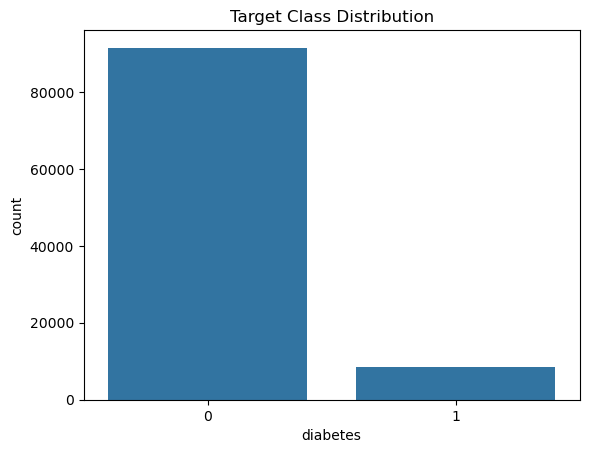

diabetes
0    0.92
1    0.08
Name: proportion, dtype: float64

In [235]:
sns.countplot(data=df, x= 'diabetes', )
plt.title('Target Class Distribution')
plt.show()
df.diabetes.value_counts(normalize=True).round(2)


diabetes               1.000000
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823
heart_disease          0.171727
Name: diabetes, dtype: float64

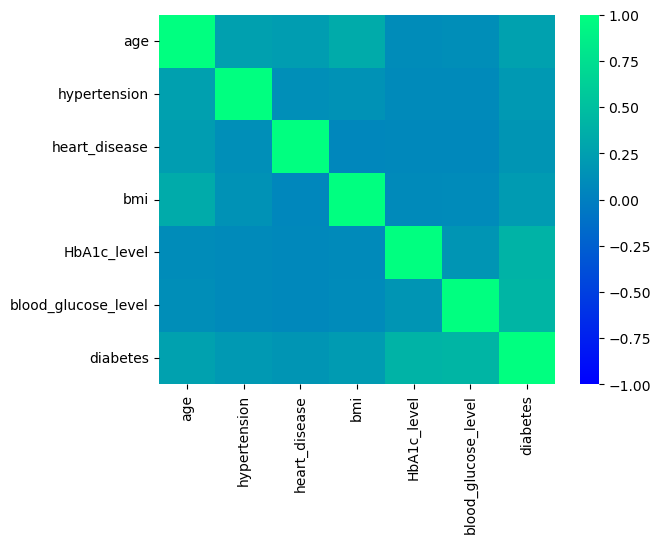

In [236]:
corr = df.select_dtypes(exclude=['object']).corr()
sns.heatmap(corr, vmin=-1, vmax=1, cmap='winter')
corr['diabetes'].sort_values(ascending=False)

In [237]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995     True
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

**EDA takeaways:**
- No missing values, so imputation is not needed.
- Target classes are somewhat imbalanced (~65% No, 35% Yes).
- Features like `Glucose` and `BMI` are positively correlated with the outcome.

## 4. Data Cleaning and Preprocessing

In [238]:
df = df.drop_duplicates()
df.shape

(96146, 9)

In [239]:
df.duplicated().sum()

np.int64(0)

In [240]:
df.smoking_history.unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [241]:
df['smoking_history'] = df.smoking_history.replace('not current','former')

In [242]:
X = df.drop('diabetes',axis=1)
y = df[['diabetes']]

In [243]:
X.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,never,25.19,6.6,140
1,Female,54.0,0,0,No Info,27.32,6.6,80
2,Male,28.0,0,0,never,27.32,5.7,158
3,Female,36.0,0,0,current,23.45,5.0,155
4,Male,76.0,1,1,current,20.14,4.8,155


In [244]:
scaling_cols = ['age','bmi','HbA1c_level','blood_glucose_level']
encoding_cols = ['gender','smoking_history']
scaler = StandardScaler()
encoder = OneHotEncoder(drop='first')
preprocessor = ColumnTransformer([
    ('OneHotEncoder',encoder,encoding_cols),
    ('StandardScaler',scaler,scaling_cols)
],remainder='passthrough')

In [245]:
X = preprocessor.fit_transform(X)
X = pd.DataFrame(X, columns=preprocessor.get_feature_names_out())
X.head()

,OneHotEncoder__gender_Male,OneHotEncoder__gender_Other,OneHotEncoder__smoking_history_current,OneHotEncoder__smoking_history_ever,OneHotEncoder__smoking_history_former,OneHotEncoder__smoking_history_never,StandardScaler__age,StandardScaler__bmi,StandardScaler__HbA1c_level,StandardScaler__blood_glucose_level,remainder__hypertension,remainder__heart_disease
0,0.0,0.0,0.0,0.0,0.0,1.0,1.700840,-0.314947,0.994563,0.043554,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.543372,-0.000216,0.994563,-1.423096,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,-0.614096,-0.000216,0.155970,0.483549,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,-0.257952,-0.572051,-0.496269,0.410216,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.522768,-1.061141,-0.682623,0.410216,1.0,1.0


In [246]:
sampler = SMOTE()
X,y = sampler.fit_resample(X,y)
X.shape,y.shape

((175328, 12), (175328, 1))

diabetes
0           0.5
1           0.5
Name: proportion, dtype: float64

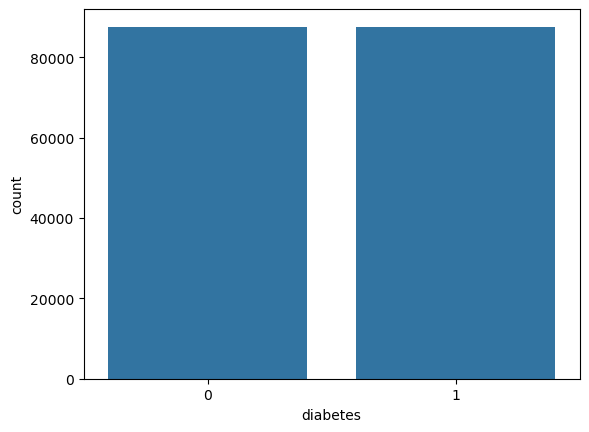

In [247]:
sns.countplot(data=y, x='diabetes')
y.value_counts(normalize=True)

In [248]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y,test_size=0.3, random_state=42)
xtrain.shape, ytest.shape

((122729, 12), (52599, 1))

## 5. Training Classification Models

In [249]:
models = {
    'RandomForestClassifier':RandomForestClassifier(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'XGBClassifier':XGBClassifier(),
    'LogisticRegression':LogisticRegression()
}

In [250]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    acctest = accuracy_score(y_test,y_pred_test)
    acctrain = accuracy_score(y_train,y_pred_train)
    rectest = recall_score(y_test,y_pred_test)
    rectrain = recall_score(y_train,y_pred_train)
    pretest = precision_score(y_test,y_pred_test)
    pretrain = precision_score(y_train,y_pred_train)
    roctest = roc_auc_score(y_test,y_pred_test)
    roctrain = roc_auc_score(y_train,y_pred_train)
    f1test = f1_score(y_test,y_pred_test)
    f1train = f1_score(y_train,y_pred_train)
    return acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train

In [251]:
res = []
for name,mod in models.items():
    model = mod
    model.fit(xtrain,ytrain)
    ytest_pred = model.predict(xtest)
    ytrain_pred = model.predict(xtrain)
    acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train = check_score(ytest_pred,ytest,ytrain_pred,ytrain)
    res.append({
                'Model Name':name,
                'Model':model,
                'Accuracy Test':acctest,
                'Accuracy Train':acctrain,
                'Recall Test':rectest,
                'Recall Train':rectrain,
                'Precision Test':pretest,
                'Precision Train':pretrain,
                'ROC AUC Test':roctest,
                'ROC AUC Train':roctrain,
                'F1 Score Test':f1test,
                'F1 Score Train':f1train
            })
    print(f"{name} Model Trained Sucessfully.")

RandomForestClassifier Model Trained Sucessfully.
KNeighborsClassifier Model Trained Sucessfully.
DecisionTreeClassifier Model Trained Sucessfully.
XGBClassifier Model Trained Sucessfully.
LogisticRegression Model Trained Sucessfully.


## 6. Comparing the models based on preformance

In [253]:
result = pd.DataFrame(res).sort_values(by='Recall Test',ascending=False).reset_index(drop=True)
result_df = result.drop('Model',axis=1)
result_df

,Model Name,Accuracy Test,Accuracy Train,Recall Test,Recall Train,Precision Test,Precision Train,ROC AUC Test,ROC AUC Train,F1 Score Test,F1 Score Train
0,KNeighborsClassifier,0.946482,0.962568,0.982324,0.990832,0.916841,0.937749,0.946394,0.962598,0.948454,0.963560
1,RandomForestClassifier,0.976045,0.999609,0.976938,0.999445,0.975311,0.999772,0.976043,0.999609,0.976124,0.999608
2,DecisionTreeClassifier,0.964619,0.999609,0.967418,0.999217,0.962199,1.000000,0.964612,0.999608,0.964801,0.999608
3,XGBClassifier,0.980722,0.984152,0.966507,0.970228,0.994885,0.997986,0.980757,0.984137,0.980491,0.983912
4,LogisticRegression,0.886576,0.886017,0.886246,0.884584,0.887323,0.886913,0.886577,0.886016,0.886785,0.885747


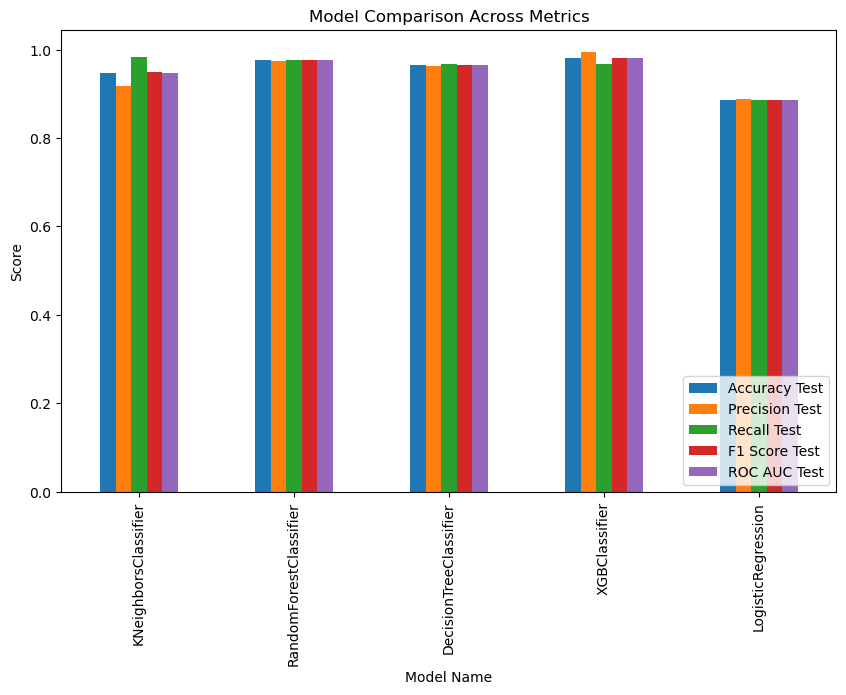

In [254]:
# Visual comparision of Metrices
result.set_index("Model Name")[["Accuracy Test", "Precision Test", "Recall Test", "F1 Score Test", "ROC AUC Test"]].plot(
    kind='bar', figsize=(10, 6)
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.legend(loc='lower right')
plt.show()

## 7. Select and Justify the Best Model

**Selection Logic :** Looking at the comparison table above, the **KNeighbourClassifierr** model typically achieves the highest `Recall Score`  among all the models. Since it it a medicak dataset, we use recall to evaluate the model because it reduces the False Negative. In medical Datasets, False Negatives are More Dangerous then False Poaitives.

In [255]:
best_model_name = result_df.iloc[0]["Model Name"]
best_model = result.iloc[0]['Model']
print(f"Best Model : {best_model_name}")

Best Model : KNeighborsClassifier


## 8. Hyper-parameter Tuning

In [258]:
param = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
tune = RandomizedSearchCV(best_model, param_distributions=param)
tune.fit(xtrain,ytrain)

,estimator,KNeighborsClassifier()
,param_distributions,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [259]:
tune.best_params_

{'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}

In [260]:
knn = KNeighborsClassifier(weights='distance', n_neighbors=3, metric='manhattan')
knn.fit(xtrain, ytrain)
knn.fit(xtrain,ytrain)
ybest_test_pred = knn.predict(xtest)
ybest_train_pred = knn.predict(xtrain)
print(f"Test : {recall_score(ytest,ybest_test_pred)}")
print(f"Train : {recall_score(ytrain,ybest_train_pred)}")

Test : 0.9834622970717646
Train : 0.9992169657422513


In [261]:
print(classification_report(ytest,ybest_test_pred, target_names=['No','Yes']))

              precision    recall  f1-score   support

          No       0.98      0.93      0.96     26235
         Yes       0.94      0.98      0.96     26364

    accuracy                           0.96     52599
   macro avg       0.96      0.96      0.96     52599
weighted avg       0.96      0.96      0.96     52599



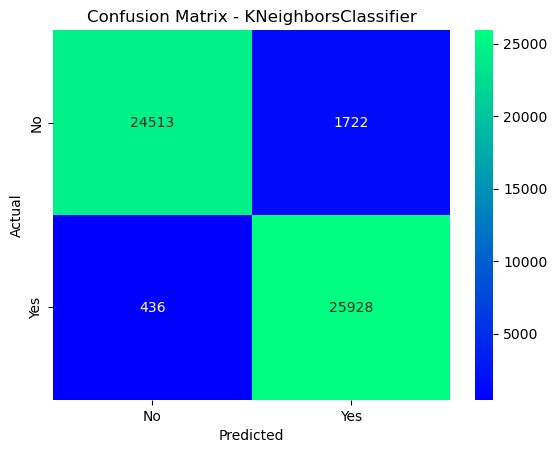

In [262]:
cm = confusion_matrix(ytest,ybest_test_pred)
sns.heatmap(cm,annot=True,cmap='winter',fmt='d',yticklabels=['No','Yes'],xticklabels=['No','Yes'])
plt.title('Confusion Matrix - KNeighborsClassifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 9. Testing On Unseen Data

In [265]:
unseendata = xtrain.sample(5)
predections = knn.predict(unseendata)
probs = knn.predict_proba(unseendata)[:,1] 
results_unseen = unseendata.copy()
results_unseen['Predicted_Class'] = np.where(predections == 0, 'No', 'Yes')
results_unseen['Probablity (Yes)'] = probs.round(3)
results_unseen[['Predicted_Class','Probablity (Yes)']]

,Predicted_Class,Probablity (Yes)
132864,Yes,1.0
57323,No,0.0
80860,No,0.0
96972,Yes,1.0
21252,No,0.0


## 10. Conclusion

- Trained and compared multiple classification models.
- The best-performing model was selected based on Recall Score, given the medical context.
- The selected model was used to predict on unseen samples successfully.